workshop 1
 bhuwan baniya

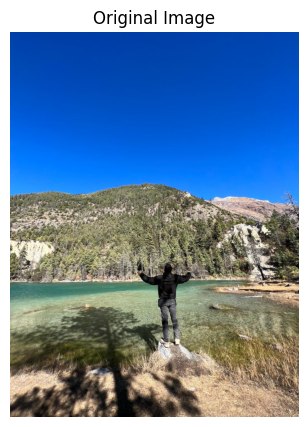

In [1]:
# Import the required libraries
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. Read and display the image
# Replace 'your_image_name.jpg' with your actual image file name
img = Image.open('image.jpg')

# Convert the image to a NumPy array so we can manipulate the pixels
img_array = np.array(img)

# Display the original image
plt.figure(figsize=(5, 5))
plt.imshow(img_array)
plt.title("Original Image")
plt.axis('off') # Hides the axis numbers
plt.show()

Step 2: Task 2 (Crop the top-left corner)

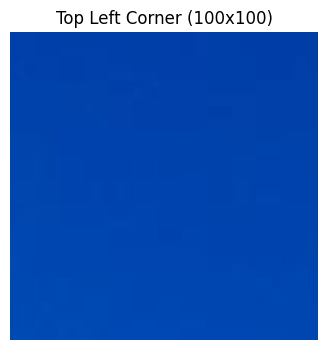

In [2]:
# 2. Extract the top-left corner (100x100 pixels) using NumPy slicing
top_left_corner = img_array[:100, :100]

# Display the cropped image
plt.figure(figsize=(4, 4))
plt.imshow(top_left_corner)
plt.title("Top Left Corner (100x100)")
plt.axis('off')
plt.show()

Step 3: Task 3 (Show R, G, B channels)

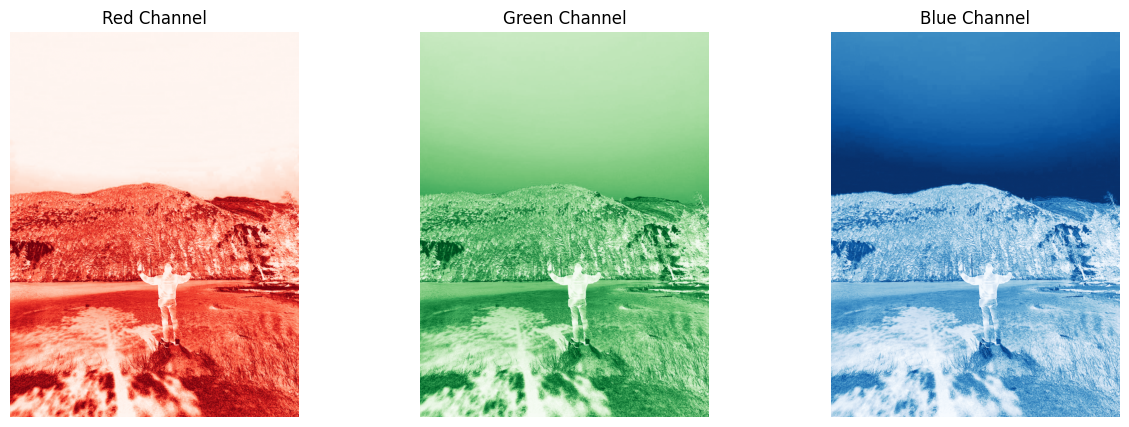

In [4]:
# 3. Separate the image into its three color channels
# Index 0 is Red, Index 1 is Green, Index 2 is Blue
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

# Create a figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot Red Channel
axes[0].imshow(R, cmap='Reds')
axes[0].set_title('Red Channel')
axes[0].axis('off')

# Plot Green Channel
axes[1].imshow(G, cmap='Greens')
axes[1].set_title('Green Channel')
axes[1].axis('off')

# Plot Blue Channel
axes[2].imshow(B, cmap='Blues')
axes[2].set_title('Blue Channel')
axes[2].axis('off')

plt.show()

Step 4: Task 4 (Modify the top 100x100 pixels)

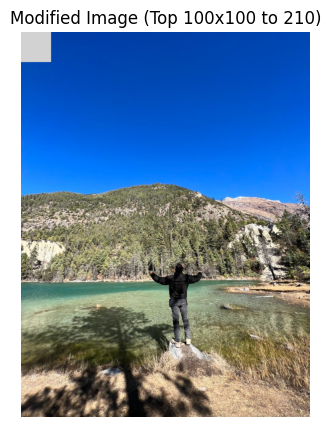

In [5]:
# 4. Modify the top 100x100 pixels to a value of 210
modified_img = img_array.copy() # Make a copy so we don't ruin the original
modified_img[:100, :100] = 210  # Set the entire 100x100 block to 210

# Display the modified image
plt.figure(figsize=(5, 5))
plt.imshow(modified_img)
plt.title("Modified Image (Top 100x100 to 210)")
plt.axis('off')
plt.show()

 Exercise 2: Grayscale Image Manipulation.
 Task 1: Load and display a grayscale image


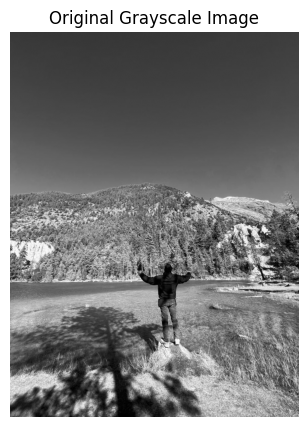

In [8]:
# 1. Load a grayscale image using the Pillow library
# Replace 'your_image_name.jpg' with your actual image file
img_gray_pil = Image.open('image.jpg').convert('L')

# Convert it to a NumPy array for processing
img_gray = np.array(img_gray_pil)

# Display the grayscale image using matplotlib
plt.figure(figsize=(5, 5))
plt.imshow(img_gray, cmap='gray') # We must specify cmap='gray' for grayscale arrays
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()

Task 2: Extract and display the middle section (150x150 pixels)


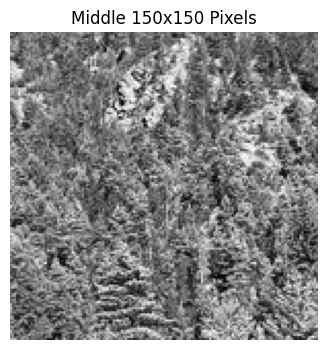

In [9]:
# 2. Extract a 150 pixel section from the center of the image
height, width = img_gray.shape
center_y, center_x = height // 2, width // 2

# Calculate the slicing boundaries (75 pixels up/down and left/right from center)
start_y = center_y - 75
end_y = center_y + 75
start_x = center_x - 75
end_x = center_x + 75

# Slice the array
middle_section = img_gray[start_y:end_y, start_x:end_x]

# Display the cropped image
plt.figure(figsize=(4, 4))
plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150x150 Pixels")
plt.axis('off')
plt.show()

Task 3: Apply a simple threshold


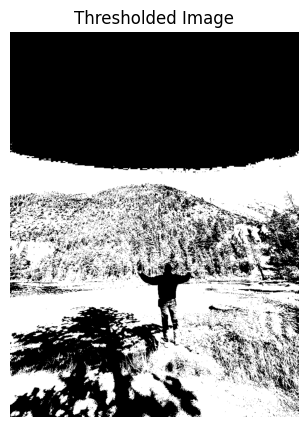

In [10]:
# 3. Apply a threshold to the grayscale image
thresholded_img = img_gray.copy() # Make a copy first

# Set pixels below 100 to 0 (Black) and pixels 100 or above to 255 (White)
thresholded_img[thresholded_img < 100] = 0
thresholded_img[thresholded_img >= 100] = 255

# Display the resulting binary image
plt.figure(figsize=(5, 5))
plt.imshow(thresholded_img, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')
plt.show()

Task 4: Rotate the image 90 degrees clockwise


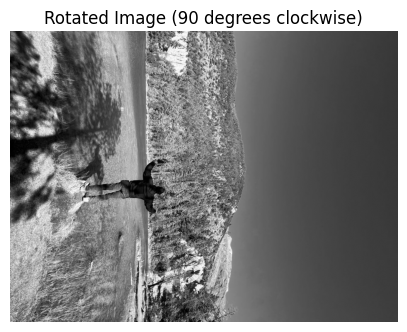

In [11]:
# 4. Rotate the image 90 degrees clockwise
# k=-1 rotates 90 degrees clockwise using NumPy
rotated_img = np.rot90(img_gray, k=-1)

# Display the rotated image
plt.figure(figsize=(5, 5))
plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated Image (90 degrees clockwise)")
plt.axis('off')
plt.show()

Task 5: Convert the grayscale image to an RGB image


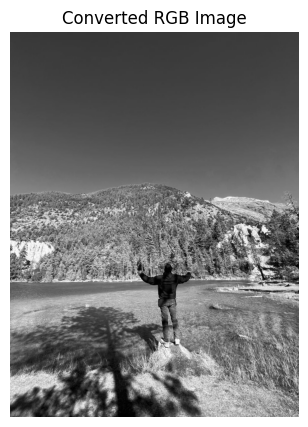

In [12]:
# 5. Convert the grayscale image into an RGB image
# We stack the grayscale array 3 times along a new depth axis (axis=2)
converted_rgb_img = np.stack((img_gray, img_gray, img_gray), axis=2)

# Display the converted RGB image
plt.figure(figsize=(5, 5))
plt.imshow(converted_rgb_img) # Notice we don't need cmap='gray' anymore because it has 3 channels!
plt.title("Converted RGB Image")
plt.axis('off')
plt.show()

Exercise 3 (PCA Compression from Scratch)

Step 1: Load, Prepare, and Standardize Data

In [14]:
# 1. Load and Prepare Data
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image and convert to grayscale
img_pil = Image.open('image.jpg').convert('L')
img_matrix = np.array(img_pil, dtype=np.float64)

# Center the dataset (Standardize by subtracting the mean of each column)
mean_vec = np.mean(img_matrix, axis=0)
centered_data = img_matrix - mean_vec

# Calculate the covariance matrix from scratch
# Formula: (X^T * X) / (n - 1)
n_samples = centered_data.shape[0]
cov_matrix = (centered_data.T @ centered_data) / (n_samples - 1)

print(f"Original Image Shape: {img_matrix.shape}")
print(f"Covariance Matrix Shape: {cov_matrix.shape}")

Original Image Shape: (1280, 960)
Covariance Matrix Shape: (960, 960)


Step 2: Eigen Decomposition and Cumulative Sum Plot


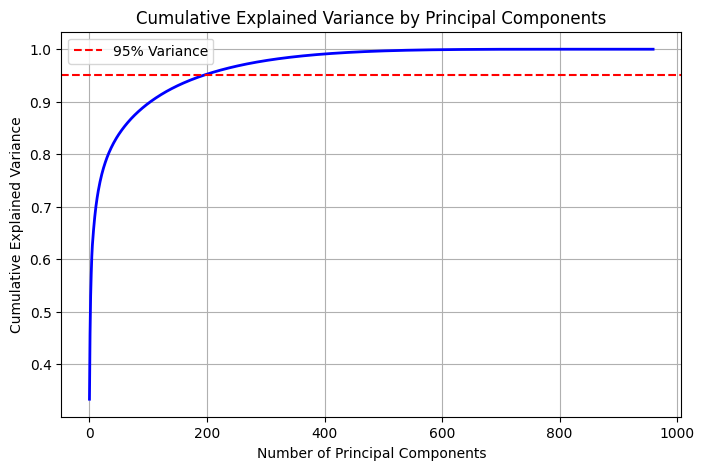

In [15]:
# 2. Compute Eigen Values and Eigen Vectors
# We use eigh because the covariance matrix is symmetric
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort the eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Calculate Explained Variance and Cumulative Sum
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

# Plot the cumulative sum to identify Principal Components
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, color='b', linewidth=2)
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance') # Reference line
plt.legend()
plt.grid(True)
plt.show()

Step 3: Reconstruction and Experiment


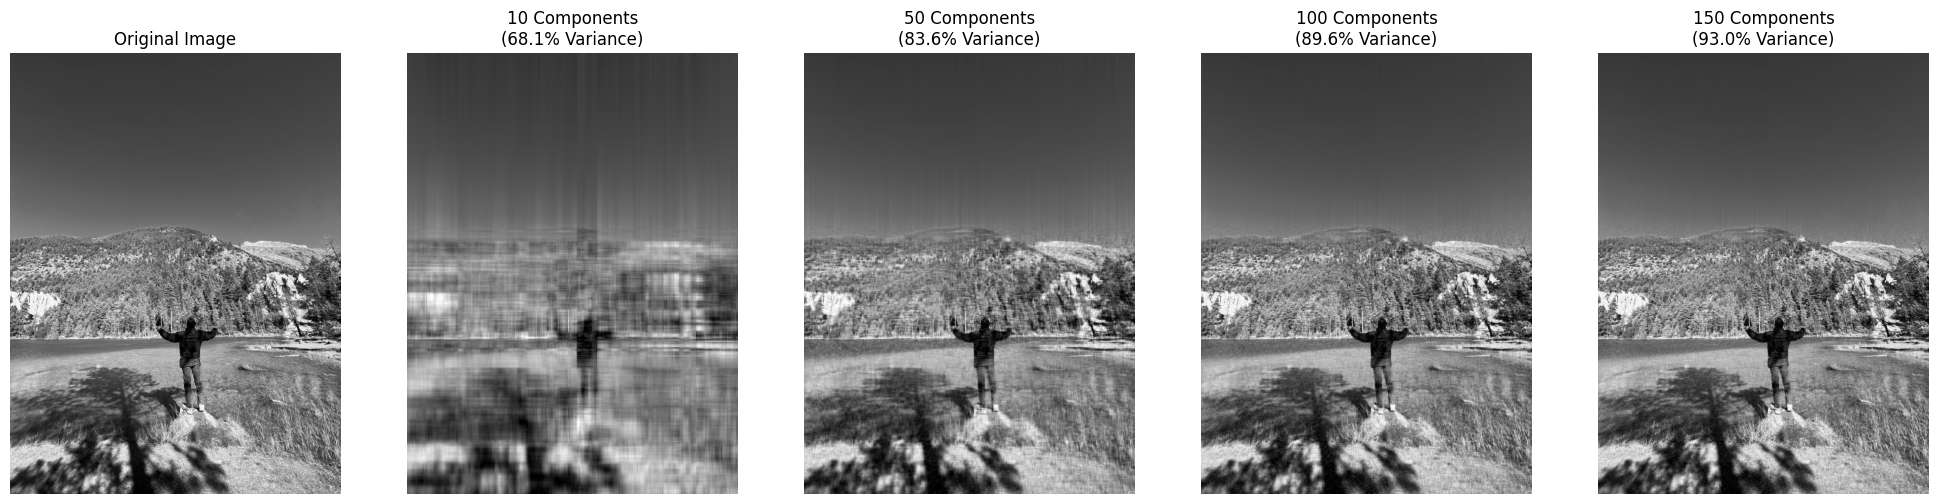

In [16]:
# 3. Reconstruction and Experiment

# Pick 4 different combinations of principal components
components_to_test = [10, 50, 100, 150]

# Set up the plot to show the Original + 4 Reconstructions side-by-side
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# Plot Original Image
axes[0].imshow(img_matrix, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Loop through our chosen components
for i, k in enumerate(components_to_test):
    # Select the top 'k' eigenvectors
    top_k_eigenvectors = eigenvectors[:, :k]

    # ---------------- COMPRESSION ----------------
    # Transform the original data to a lower-dimensional space
    compressed_data = centered_data @ top_k_eigenvectors

    # --------------- RECONSTRUCTION --------------
    # Reconstruct the image back to original dimensions and add the mean back
    reconstructed_data = (compressed_data @ top_k_eigenvectors.T) + mean_vec

    # Clip pixel values so they stay between 0 and 255 (valid image range)
    reconstructed_data = np.clip(reconstructed_data, 0, 255)

    # Calculate explained variance for this specific 'k'
    var_explained = cumulative_variance[k-1] * 100

    # Plot the reconstructed image
    axes[i+1].imshow(reconstructed_data, cmap='gray')
    axes[i+1].set_title(f'{k} Components\n({var_explained:.1f}% Variance)')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()